# Generación de inputs para simulaciones en Hec-HMS

Es fundamental utilizar diferentes fuentes de datos para la correcta parametrización en la construcción de modelos hidrológicos en **HEC-HMS**. Entre las fuentes de datos esenciales se encuentran la **litología** y los **usos del suelo**, ya que permiten obtener los parámetros clave necesarios para la modelización hidrológica.  

Para este propósito, se emplean bases de datos como [**CORINE**](https://land.copernicus.eu/en/products/corine-land-cover), que proporciona información sobre los usos del suelo, y [**ISRIC**](https://data.isric.org/geonetwork/srv/api/records/f9a3a4e0-27a8-4acc-861f-26c112699c3e), que ofrece datos detallados sobre la caracterización de los suelos. Estas fuentes de información son indispensables para asegurar una representación precisa de las condiciones hidrológicas del área de estudio.


In [83]:
import numpy as np
import math

## Pasos previos a realizar

Después de extraer las cuencas y subcuencas, junto con los cauces a partir del terreno utilizando las funciones GIS de HEC-HMS, es necesario calcular las características de **subbasin** y **reach**. Este paso es fundamental para garantizar un adecuado modelado hidrológico y debe realizarse antes de la preconfiguración del modelo.  

Además, es necesario **exportar la tabla de características** obtenida y los **shapefiles** correspondientes tanto de **subbasin** como de **ríos**. Esto permitirá su uso posterior en la configuración y análisis del modelo hidrológico.  

Una vez realizados estos pasos, se procede a preconfigurar el modelo con los distintos parámetros que queremos considerar.  

Este código configura los siguientes parámetros:  

**Canopy**  
- Simple Canopy  

**Superficie**  
- Simple Surface  

**Pérdidas (Loss)**  
- SCS Curve Number  
- Soil Moisture Accounting  

**Transformación (Transform)**  
- Clark Unit Hydrograph  

**Baseflow**  
- Linear Reservoir  

**Enrutamiento (Routing)**  
- Muskingum  

**Pérdidas/Ganancias (Loss/Gain)**  
- Constant  

## Cálculo del número de curva

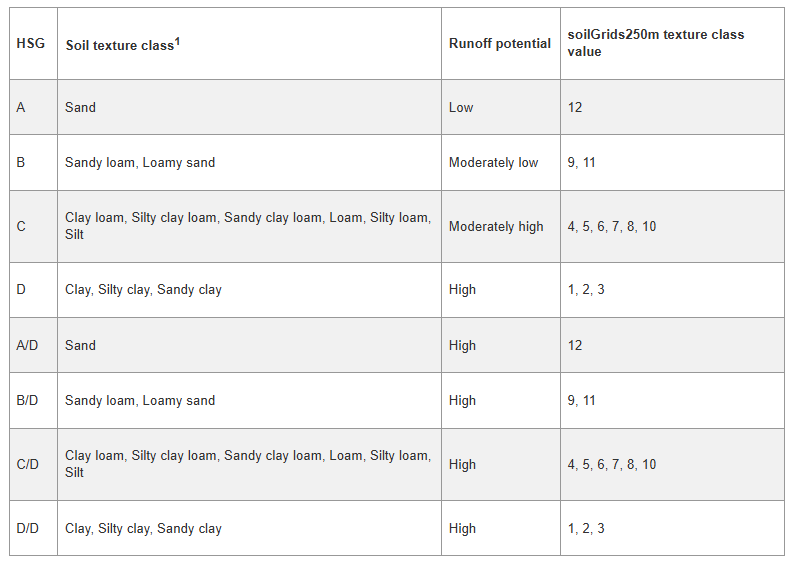

Los datos de litología son obtenidos y preprocesados desde [ISRIC](https://files.isric.org/soilgrids/former/2017-03-10/data/) utilizazando este código: 

https://www.hydroshare.org/resource/1361509511e44adfba814f6950c6e742/


| #   | Textura del Suelo        |
|-----|--------------------------|
| 1   | Clay                    |
| 2   | Clay loam               |
| 3   | Loam                   |
| 4   | Loamy sand             |
| 5   | Sand                   |
| 6   | Sandy clay             |
| 7   | Sandy clay loam        |
| 8   | Sandy loam             |
| 9   | Silt                   |
| 10  | Silty clay             |
| 11  | Silty clay loam        |
| 12  | Silt loam              |


### Resumen de Texturas:
| Bloque | Textura                 | Descripción                                      |
|--------|-------------------------|--------------------------------------------------|
| 1      | Arcilla (clay)          | Alto contenido de arcilla, bajo arena y limo.    |
| 2      | Arcilla limosa (silty clay) | Moderada arcilla, arena 20-45%, limo variable.   |
| 3      | Franco arcillo-limoso (clay loam) | Moderada arcilla, limo 28-50%, arena <52%.       |
| 4      | Franco limoso (silt loam) | Equilibrio de limo y arcilla.                    |
| 5      | Franco arenoso (sandy loam) | Bajo limo y arcilla, dominado por arena.         |
| 6      | Arcilla arenosa (sandy clay) | Alta arcilla y arena.                            |
| 7      | Franco arcillo-arenoso (clayey sand) | Moderada arcilla, baja limo, alta arena.         |
| 8      | Franco arenoso-limoso (sandy silt loam) | Variable arena, limo y arcilla.                  |
| 9      | Limo (silt)             | Muy alto limo, baja arcilla.                     |
| 10     | Arcilla limosa (silty clay) | Alta arcilla y limo.                             |
| 11     | Franco arcilloso (clay loam) | Moderada arcilla, baja arena.                    |
| 12     | Franco limoso (silt loam) | Alto limo, variable arcilla.                     |

In [ ]:
import pandas as pd
import numpy as np

def calculate_clark_parameters(csv_file, output_csv):
    """
    Calcula los parámetros del modelo de Clark (Tiempo de concentración Tc y Coeficiente de almacenamiento R)
    basado en las propiedades de las cuencas.
    
    Parámetros:
    - csv_file: Ruta al archivo CSV de entrada con las propiedades de las cuencas.
    - output_csv: Ruta al archivo CSV donde se guardarán los resultados.

    Devuelve:
    - DataFrame con los parámetros calculados.
    """
    # Cargar los datos del CSV
    basin_properties = pd.read_csv(csv_file)
    
    # Asegurar que las columnas necesarias estén en el DataFrame
    required_columns = ["Longest Flowpath Length (KM)", "Centroidal Flowpath Length (KM)", "10-85 Flowpath Slope"]
    if not all(col in basin_properties.columns for col in required_columns):
        raise ValueError(f"El archivo CSV debe contener las siguientes columnas: {required_columns}")

    # Convertir unidades (de KM a millas y Slope de m/m a ft/ft)
    basin_properties["Longest Flowpath Length (miles)"] = basin_properties["Longest Flowpath Length (KM)"] * 0.621371
    basin_properties["Centroidal Flowpath Length (miles)"] = basin_properties["Centroidal Flowpath Length (KM)"] * 0.621371
    basin_properties["10-85 Flowpath Slope (ft/ft)"] = basin_properties["10-85 Flowpath Slope"] * 5280

    # Calcular el tiempo de concentración Tc (Clark)
    basin_properties["Clark Tc (hours)"] = 2.2 * (
        basin_properties["Longest Flowpath Length (miles)"] * basin_properties["Centroidal Flowpath Length (miles)"] /
        np.sqrt(basin_properties["10-85 Flowpath Slope (ft/ft)"])
    ) ** 0.3

    # Calcular el coeficiente de almacenamiento R
    basin_properties["Clark R (hours)"] = 0.5 * basin_properties["Clark Tc (hours)"]

    # Guardar los resultados en un nuevo CSV
    basin_properties.to_csv(output_csv, index=False)
    
    return basin_properties

In [ ]:
import re

def update_basin_transform_parameters(basin_file_path, df):
    """
    Actualiza los parámetros de transformación en el archivo .basin de HEC-HMS,
    dentro de la sección "Transform: Clark" para cada subcuenca.

    Parámetros actualizados en la sección Transform:
      - Time of Concentration     (valor: Tc)
      - Storage Coefficient       (valor: R)
      - Clark Method              (valor fijo: "Specified")

    Se asume que el DataFrame `df` tiene el índice "name" y contiene las siguientes columnas:
      "Tc" (Time of Concentration)
      "R"  (Storage Coefficient)
    """

    # ✅ Asegurar que el índice está en el formato correcto
    df.index = df.index.astype(str).str.strip()

    # Crear diccionario de parámetros para cada subcuenca
    transform_dict = df[["Tc", "R"]].to_dict("index")

    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    new_lines = []
    current_subbasin = None
    in_transform_block = False
    transform_params_updated = set()

    for line in lines:
        stripped = line.strip()

        # Detectar el inicio de una Subcuenca
        if stripped.startswith("Subbasin:"):
            parts = stripped.split(":", 1)
            current_subbasin = parts[1].strip() if len(parts) > 1 else None
            new_lines.append(line)
            continue

        # Detectar el inicio del bloque de Transformación Clark
        if stripped.startswith("Transform: Clark"):
            in_transform_block = True
            transform_params_updated.clear()
            new_lines.append(line)
            continue

        # Si estamos dentro del bloque de Transformación Clark
        if in_transform_block:
            # Detectar fin del bloque Transform
            if stripped.startswith("Time Area Method:") or stripped.startswith("End:"):
                if current_subbasin and current_subbasin in transform_dict:
                    params = transform_dict[current_subbasin]
                    mapping = {
                        "Clark Method": "Specified",
                        "Time of Concentration": params["Tc"],
                        "Storage Coefficient": params["R"]
                    }
                    for param, value in mapping.items():
                        if param not in transform_params_updated:
                            new_lines.append(f"     {param}: {value}\n")
                            transform_params_updated.add(param)
                new_lines.append(line)
                in_transform_block = False
                continue

            # Si estamos dentro del bloque, actualizar los parámetros
            if current_subbasin and current_subbasin in transform_dict:
                params = transform_dict[current_subbasin]
                mapping = {
                    "Clark Method": "Specified",
                    "Time of Concentration": params["Tc"],
                    "Storage Coefficient": params["R"]
                }
                updated = False
                for param, value in mapping.items():
                    if stripped.startswith(param + ":"):
                        new_lines.append(f"     {param}: {value}\n")
                        transform_params_updated.add(param)
                        updated = True
                        break
                if not updated:
                    new_lines.append(line)
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)

    # Guardar el archivo actualizado
    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente en el bloque de Transform.")


In [3]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import os


def reproject_to_match_crs(input_raster, reference_raster, output_path):
    """
    Reproyecta un raster al CRS de referencia.

    Args:
        input_raster (str): Ruta al raster de entrada.
        reference_raster (str): Ruta al raster de referencia (CRS objetivo).
        output_path (str): Ruta al archivo reproyectado.

    Returns:
        str: Ruta al archivo reproyectado.
    """
    with rasterio.open(input_raster) as src:
        with rasterio.open(reference_raster) as ref:
            # Comprobar si los CRS son iguales
            if src.crs == ref.crs:
                print(f"El CRS de {input_raster} ya coincide con el CRS del raster de referencia.")
                return input_raster  # No se requiere reproyección

            # Calcular la transformación para reproyectar
            transform, width, height = calculate_default_transform(
                src.crs, ref.crs, src.width, src.height, *src.bounds
            )

            # Actualizar metadatos
            kwargs = src.meta.copy()
            kwargs.update({
                'crs': ref.crs,
                'transform': transform,
                'width': width,
                'height': height
            })

            # Guardar el raster reproyectado
            with rasterio.open(output_path, 'w', **kwargs) as dst:
                for i in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, i),
                        destination=rasterio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=ref.crs,
                        resampling=Resampling.bilinear
                    )

    print(f"El raster {input_raster} ha sido reproyectado al CRS del raster de referencia.")
    return output_path


def get_min_resolution_and_bounds(rasters):
    """
    Determina la resolución mínima y la extensión más pequeña (bounding box) entre varios rasters.

    Args:
        rasters (list of str): Lista de rutas a los rasters.

    Returns:
        tuple: Resolución mínima y extensión mínima (xmin, ymin, xmax, ymax).
    """
    min_resolution = None
    min_bounds = None

    for raster_path in rasters:
        with rasterio.open(raster_path) as raster:
            # Resolución mínima
            resolution = raster.res[0]
            if min_resolution is None or resolution < min_resolution:
                min_resolution = resolution

            # Extensión mínima
            bounds = raster.bounds
            if min_bounds is None:
                min_bounds = bounds
            else:
                min_bounds = (
                    max(min_bounds[0], bounds[0]),  # xmin
                    max(min_bounds[1], bounds[1]),  # ymin
                    min(min_bounds[2], bounds[2]),  # xmax
                    min(min_bounds[3], bounds[3])   # ymax
                )

    return min_resolution, min_bounds


def align_and_resample_raster(input_raster, reference_bounds, reference_resolution, output_path):
    """
    Reamuestra y recorta un raster al tamaño de celda y extensión especificados.

    Args:
        input_raster (str): Ruta al raster de entrada.
        reference_bounds (tuple): Extensión objetivo (xmin, ymin, xmax, ymax).
        reference_resolution (float): Resolución objetivo.
        output_path (str): Ruta al archivo de salida.

    Returns:
        str: Ruta al archivo reamuestrado.
    """
    with rasterio.open(input_raster) as src:
        transform, width, height = calculate_default_transform(
            src.crs, src.crs, width=src.width, height=src.height,
            left=reference_bounds[0], bottom=reference_bounds[1],
            right=reference_bounds[2], top=reference_bounds[3],
            resolution=(reference_resolution, reference_resolution)
        )

        kwargs = src.meta.copy()
        kwargs.update({
            'transform': transform,
            'width': width,
            'height': height,
            'compress': 'lzw'
        })

        with rasterio.open(output_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=src.crs,
                    resampling=Resampling.bilinear
                )

    return output_path


def calculate_curve_number(texture_rasters, land_use_raster, output_path, corine_to_cn, texture_to_hsg):
    """
    Calcula el Número de Curva (CN) basado en las texturas del suelo y el uso del suelo.

    Args:
        texture_rasters (list of str): Rutas a los rasters de textura alineados.
        land_use_raster (str): Ruta al raster de uso del suelo alineado.
        output_path (str): Ruta de salida del raster CN.
        corine_to_cn (dict): Diccionario con los valores CN por uso del suelo y HSG.
        texture_to_hsg (dict): Diccionario que mapea texturas a grupos hidrológicos (HSG).

    Returns:
        str: Ruta al raster CN calculado.
    """
    # Abrir el raster de uso del suelo
    with rasterio.open(land_use_raster) as land_use:
        land_use_data = land_use.read(1)
        meta = land_use.meta.copy()

    # Abrir los rasters de textura
    texture_data = []
    for texture_raster in texture_rasters:
        with rasterio.open(texture_raster) as texture:
            texture_data.append(texture.read(1))

    # Calcular el HSG más restrictivo por celda
    hsg_data = np.full_like(land_use_data, "A", dtype="object")
    for y in range(hsg_data.shape[0]):
        for x in range(hsg_data.shape[1]):
            hsg_values = [
                texture_to_hsg.get(texture_data[layer][y, x], "A") for layer in range(len(texture_data))
            ]
            hsg_data[y, x] = min(hsg_values, key=lambda hsg: {"A": 4, "B": 3, "C": 2, "D": 1}[hsg])

    # Calcular el Número de Curva (CN)
    cn_data = np.zeros_like(land_use_data, dtype=float)
    for y in range(land_use_data.shape[0]):
        for x in range(land_use_data.shape[1]):
            land_use_code = land_use_data[y, x]
            hsg = hsg_data[y, x]
            if land_use_code in corine_to_cn and hsg in corine_to_cn[land_use_code]:
                cn_data[y, x] = corine_to_cn[land_use_code][hsg]

    # Guardar el raster CN
    meta.update(dtype=rasterio.float32)
    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(cn_data, 1)

    return output_path


def process_all_rasters(texture_rasters, land_use_raster, output_dir):
    """
    Procesa y alinea todos los rasters al tamaño de celda y extensión mínima.

    Args:
        texture_rasters (list of str): Lista de rutas a los rasters de textura de suelo.
        land_use_raster (str): Ruta al raster de uso del suelo.
        output_dir (str): Directorio para guardar los archivos alineados.

    Returns:
        tuple: Rutas a los rasters de textura alineados y al raster de uso del suelo alineado.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Determinar resolución y extensión mínimas
    min_resolution, min_bounds = get_min_resolution_and_bounds(texture_rasters + [land_use_raster])

    # Procesar texturas
    aligned_textures = []
    for i, raster_path in enumerate(texture_rasters):
        output_path = os.path.join(output_dir, f"aligned_texture_{i}.tif")
        aligned_texture = align_and_resample_raster(raster_path, min_bounds, min_resolution, output_path)
        aligned_textures.append(aligned_texture)

    # Procesar uso del suelo
    output_land_use_path = os.path.join(output_dir, "aligned_land_use.tif")
    aligned_land_use = align_and_resample_raster(land_use_raster, min_bounds, min_resolution, output_land_use_path)

    return aligned_textures, aligned_land_use


# Diccionarios necesarios para el cálculo
texture_to_hsg = {
    1: "D", 2: "C", 3: "C", 4: "B", 5: "A", 6: "D", 7: "C", 8: "B",
    9: "C", 10: "D", 11: "C", 12: "C"
}
corine_to_cn = {
    # 1. Artificial Surfaces
    1: {"A": 85, "B": 89, "C": 92, "D": 94},  # Continuous urban fabric
    2: {"A": 65, "B": 77, "C": 85, "D": 90},  # Discontinuous urban fabric
    3: {"A": 81, "B": 88, "C": 91, "D": 93},  # Industrial or commercial units
    4: {"A": 83, "B": 89, "C": 92, "D": 94},  # Road and rail networks
    5: {"A": 83, "B": 89, "C": 92, "D": 94},  # Port areas
    6: {"A": 77, "B": 86, "C": 91, "D": 94},  # Airports
    7: {"A": 77, "B": 86, "C": 91, "D": 94},  # Mineral extraction sites
    8: {"A": 77, "B": 86, "C": 91, "D": 94},  # Dump sites
    9: {"A": 77, "B": 86, "C": 91, "D": 94},  # Construction sites
    10: {"A": 39, "B": 61, "C": 74, "D": 80},  # Green urban areas
    11: {"A": 39, "B": 61, "C": 74, "D": 80},  # Sport and leisure facilities

    # 2. Agricultural Areas
    12: {"A": 67, "B": 78, "C": 85, "D": 89},  # Non-irrigated arable land
    13: {"A": 65, "B": 75, "C": 83, "D": 87},  # Permanently irrigated land
    14: {"A": 64, "B": 75, "C": 83, "D": 86},  # Rice fields
    15: {"A": 60, "B": 70, "C": 79, "D": 84},  # Vineyards
    16: {"A": 57, "B": 68, "C": 78, "D": 83},  # Fruit trees and berry plantations
    17: {"A": 55, "B": 66, "C": 77, "D": 82},  # Olive groves
    18: {"A": 39, "B": 61, "C": 74, "D": 80},  # Pastures
    19: {"A": 62, "B": 72, "C": 81, "D": 85},  # Annual crops associated with permanent crops
    20: {"A": 60, "B": 70, "C": 79, "D": 84},  # Complex cultivation patterns
    21: {"A": 58, "B": 69, "C": 78, "D": 83},  # Land occupied by agriculture with natural vegetation
    22: {"A": 57, "B": 68, "C": 77, "D": 82},  # Agro-forestry areas

    # 3. Forest and Semi-Natural Areas
    23: {"A": 30, "B": 55, "C": 70, "D": 77},  # Broad-leaved forest
    24: {"A": 30, "B": 55, "C": 70, "D": 77},  # Coniferous forest
    25: {"A": 30, "B": 55, "C": 70, "D": 77},  # Mixed forest
    26: {"A": 39, "B": 61, "C": 74, "D": 80},  # Natural grasslands
    27: {"A": 48, "B": 67, "C": 77, "D": 83},  # Moors and heathland
    28: {"A": 48, "B": 67, "C": 77, "D": 83},  # Sclerophyllous vegetation
    29: {"A": 35, "B": 56, "C": 70, "D": 77},  # Transitional woodland-shrub
    30: {"A": 77, "B": 86, "C": 91, "D": 94},  # Beaches, dunes, sands
    31: {"A": 30, "B": 55, "C": 70, "D": 77},  # Bare rocks
    32: {"A": 48, "B": 67, "C": 77, "D": 83},  # Sparsely vegetated areas
    33: {"A": 77, "B": 86, "C": 91, "D": 94},  # Burnt areas
    34: {"A": 77, "B": 86, "C": 91, "D": 94},  # Glaciers and perpetual snow

    # 4. Wetlands
    35: {"A": 59, "B": 70, "C": 80, "D": 85},  # Inland marshes
    36: {"A": 58, "B": 69, "C": 78, "D": 83},  # Peat bogs
    37: {"A": 59, "B": 70, "C": 80, "D": 85},  # Salt marshes
    38: {"A": 59, "B": 70, "C": 80, "D": 85},  # Salines
    39: {"A": 59, "B": 70, "C": 80, "D": 85},  # Intertidal flats

    # 5. Water Bodies
    40: {"A": 100, "B": 100, "C": 100, "D": 100},  # Water courses
    41: {"A": 100, "B": 100, "C": 100, "D": 100},  # Water bodies
    42: {"A": 100, "B": 100, "C": 100, "D": 100},  # Coastal lagoons
    43: {"A": 100, "B": 100, "C": 100, "D": 100},  # Estuaries
    44: {"A": 100, "B": 100, "C": 100, "D": 100},  # Sea and ocean

    # NODATA
    48: {"A": 0, "B": 0, "C": 0, "D": 0}  # NODATA
}

# Flujo principal
texture_rasters = [
    "F:/ISRIC/data/USDA/usda_soilclass_sl1_250m_ll.tif",
    "F:/ISRIC/data/USDA/usda_soilclass_sl2_250m_ll.tif",
    "F:/ISRIC/data/USDA/usda_soilclass_sl3_250m_ll.tif",
    "F:/ISRIC/data/USDA/usda_soilclass_sl4_250m_ll.tif"
]

land_use_raster = "F:/HUELVA/01_DATA/03_LAND_USES/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif"
output_dir = "F:/HUELVA/01_DATA/04_CURVE_NUMBER/"

# Reproyectar si es necesario
reprojected_land_use_raster = reproject_to_match_crs(land_use_raster, texture_rasters[0], f"{output_dir}/reprojected_land_use.tif")

# Procesar todos los rasters
aligned_textures, aligned_land_use = process_all_rasters(texture_rasters, reprojected_land_use_raster, output_dir)

# Calcular el CN
output_cn_raster = calculate_curve_number(aligned_textures, aligned_land_use, f"{output_dir}/curve_number.tif", corine_to_cn, texture_to_hsg)

print("Procesamiento completado. Archivo CN generado:", output_cn_raster)


El CRS de F:/HUELVA/01_DATA/03_LAND_USES/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif ya coincide con el CRS del raster de referencia.
Procesamiento completado. Archivo CN generado: F:/HUELVA/01_DATA/04_CURVE_NUMBER//curve_number.tif


In [4]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterstats import zonal_stats

def extract_curve_number_abstraction_impervious(shapefile_path, curve_number_raster_path, land_use_raster_path, output_csv=None):
    """
    Extrae los valores medios del Número de Curva (Curve Number), calcula la Abstracción Inicial (IA) y el
    porcentaje de área impermeable para cada polígono en un shapefile, asegurando que el shapefile y los rasters
    tengan el mismo sistema de coordenadas.

    Args:
        shapefile_path (str): Ruta del shapefile con las regiones de interés.
        curve_number_raster_path (str): Ruta del raster de Curve Number.
        land_use_raster_path (str): Ruta del raster de uso del suelo para calcular la impermeabilidad.
        output_csv (str, opcional): Ruta donde se guardará el archivo CSV con los valores extraídos.
                                    Si es None, no se guardará el CSV.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame con los valores medios de Curve Number, Abstracción Inicial y Porcentaje Impermeable.
    """
    # Cargar shapefile
    gdf = gpd.read_file(shapefile_path)

    # Obtener la proyección del raster de Curve Number
    with rasterio.open(curve_number_raster_path) as src:
        raster_crs = src.crs

    # Verificar si los CRS son diferentes y reproyectar si es necesario
    if gdf.crs != raster_crs:
        print(f"⚠️ Reproyectando shapefile de {gdf.crs} a {raster_crs}...")
        gdf = gdf.to_crs(raster_crs)

    # Calcular estadísticas zonales para extraer el Curve Number
    stats_cn = zonal_stats(gdf, curve_number_raster_path, stats=["mean"], nodata=np.nan)
    gdf["Curve Number"] = [s["mean"] if s["mean"] is not None else np.nan for s in stats_cn]

    # Función para calcular la Abstracción Inicial (IA)
    def calculate_initial_abstraction(cn):
        if cn is None or cn <= 0 or cn > 100:
            return np.nan  # Si el CN no es válido, asignar NaN
        S = (25400 / cn) - 254  # Calcular retención potencial S
        IA = 0.2 * S  # Calcular abstracción inicial
        return round(IA, 2)

    # Aplicar cálculo de Abstracción Inicial (IA) a cada fila del GeoDataFrame
    gdf["Initial Abstraction"] = gdf["Curve Number"].apply(calculate_initial_abstraction)

    # Diccionario de porcentaje de impermeabilidad basado en CORINE Land Cover
    corine_to_impervious = {
        1: 95, 2: 70, 3: 85, 4: 90, 5: 85, 6: 50, 7: 30, 8: 20, 9: 40,
        10: 15, 11: 10, 12: 10, 13: 5, 14: 5, 15: 5, 16: 5, 17: 5, 18: 5,
        19: 5, 20: 5, 21: 5, 22: 5, 23: 2, 24: 2, 25: 2, 26: 2, 27: 2,
        28: 2, 29: 2, 30: 5, 31: 1, 32: 1, 33: 1, 34: 0, 35: 10, 36: 10,
        37: 10, 38: 10, 39: 10, 40: 100, 41: 100, 42: 100, 43: 100, 44: 100, 48: 0
    }

    # Obtener la proyección del raster de uso del suelo
    with rasterio.open(land_use_raster_path) as src:
        land_use_crs = src.crs

    # Verificar si hay diferencias de CRS y reproyectar si es necesario
    if gdf.crs != land_use_crs:
        print(f"⚠️ Reproyectando shapefile de {gdf.crs} a {land_use_crs}...")
        gdf = gdf.to_crs(land_use_crs)

    # Calcular estadísticas zonales para extraer la impermeabilidad
    stats_impervious = zonal_stats(gdf, land_use_raster_path, categorical=True, nodata=np.nan)

    # Calcular porcentaje medio de área impermeable
    impervious_values_list = []
    for region_stats in stats_impervious:
        total_pixels = sum(region_stats.values())
        if total_pixels == 0:
            impervious_values_list.append(np.nan)
            continue
        impervious_percentage = sum(corine_to_impervious.get(code, 0) * count for code, count in region_stats.items()) / total_pixels
        impervious_values_list.append(round(impervious_percentage, 2))

    gdf['Percent Impervious Area'] = impervious_values_list

    # Guardar resultados en CSV si se proporciona la ruta
    if output_csv:
        gdf.to_csv(output_csv, index=False)
        print(f"✅ Resultados guardados en: {output_csv}")

    return gdf


In [5]:
shapefile_path           = "F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/shp/subbasins.shp"
curve_number_raster_path = "F:/HUELVA/01_DATA/04_CURVE_NUMBER/curve_number.tif"
land_use_raster_path     = "F:/HUELVA/01_DATA/03_LAND_USES/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif"

In [40]:
curve_number_gdf = extract_curve_number_abstraction_impervious(shapefile_path, curve_number_raster_path,land_use_raster_path)

⚠️ Reproyectando shapefile de EPSG:32630 a EPSG:4326...


In [41]:
curve_number_gdf

,name,centroid_x,centroid_y,area_sqkm,latitude,longitude,basinid,geometry,Curve Number,Initial Abstraction,Percent Impervious Area
0,Sub1,170982.722916,4.182334e+06,1070.495625,37.729194,-6.733106,0,"MULTIPOLYGON (((-6.57041 37.89847, -6.57013 37...",73.161015,18.64,4.23
1,Sub2,148906.266369,4.177980e+06,607.230000,37.681861,-6.980955,1,"POLYGON ((-7.03674 37.85613, -7.03646 37.85614...",73.401921,18.41,3.80
2,Sub3,175818.102443,4.153518e+06,1732.637500,37.471727,-6.665591,2,"MULTIPOLYGON (((-6.74517 37.5944, -6.74489 37....",76.561408,15.55,7.61
3,Sub4,140947.752431,4.148604e+06,682.506875,37.414660,-7.056626,3,"POLYGON ((-7.16679 37.60817, -7.16595 37.6082,...",76.225141,15.84,9.56
4,Sub5,151012.909575,4.122788e+06,4.252500,37.186352,-6.931037,4,"MULTIPOLYGON (((-6.93896 37.1996, -6.93868 37....",89.656250,5.86,74.54


In [6]:
import re
import pandas as pd

def update_basin_file_from_dataframe(basin_file_path, df):
    """
    Edita o agrega los valores de Curve Number, Initial Abstraction y Percent Impervious Area en un archivo .basin de HEC-HMS
    dentro de la sección "LossRate: SCS", utilizando un DataFrame con los parámetros de las subcuencas.

    Args:
        basin_file_path (str): Ruta del archivo .basin.
        df (pd.DataFrame): DataFrame con los parámetros a modificar.
            Debe contener las columnas: 'name', 'Curve Number', 'Initial Abstraction', 'Percent Impervious Area'.

    Returns:
        None
    """
    # Convertir DataFrame en un diccionario para fácil acceso
    subbasin_parameters = df.set_index("name")[["Curve Number", "Initial Abstraction", "Percent Impervious Area"]].to_dict(orient="index")

    with open(basin_file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    new_lines = []
    in_subbasin = False
    in_lossrate_scs = False
    current_subbasin = None

    for line in lines:
        stripped_line = line.strip()

        # Detectar el inicio de una subcuenca
        match = re.match(r"Subbasin:\s+(\S+)", stripped_line)
        if match:
            current_subbasin = match.group(1)
            in_subbasin = current_subbasin in subbasin_parameters

        # Detectar el bloque de LossRate: SCS
        if in_subbasin and stripped_line.startswith("LossRate: SCS"):
            in_lossrate_scs = True

        # Si estamos dentro de la subcuenca y dentro de LossRate: SCS, verificar si hay que modificar/agregar parámetros
        if in_subbasin and in_lossrate_scs and current_subbasin in subbasin_parameters:
            if stripped_line.startswith("Curve Number:"):
                line = f"     Curve Number: {subbasin_parameters[current_subbasin]['Curve Number']}\n"
            elif stripped_line.startswith("Initial Abstraction:"):
                line = f"     Initial Abstraction: {subbasin_parameters[current_subbasin]['Initial Abstraction']}\n"
            elif stripped_line.startswith("Percent Impervious Area:"):
                line = f"     Percent Impervious Area: {subbasin_parameters[current_subbasin]['Percent Impervious Area']}\n"

        new_lines.append(line)

        # Si llegamos al final del bloque de LossRate: SCS y los valores no estaban, agregarlos antes de "Transform:"
        if in_lossrate_scs and stripped_line.startswith("Transform:"):
            if not any("Curve Number:" in l for l in new_lines[-20:]):
                new_lines.insert(-1, f"     Curve Number: {subbasin_parameters[current_subbasin]['Curve Number']}\n")
            if not any("Initial Abstraction:" in l for l in new_lines[-20:]):
                new_lines.insert(-1, f"     Initial Abstraction: {subbasin_parameters[current_subbasin]['Initial Abstraction']}\n")
            if not any("Percent Impervious Area:" in l for l in new_lines[-20:]):
                new_lines.insert(-1, f"     Percent Impervious Area: {subbasin_parameters[current_subbasin]['Percent Impervious Area']}\n")
            in_lossrate_scs = False  # Terminar edición de la subcuenca actual

    # Guardar los cambios en el archivo
    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente.")


In [43]:
update_basin_file_from_dataframe('F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin', curve_number_gdf)

✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente.


## Parámetros Soil Moisture Accounting 

In [68]:
corine_parameters = {
    1: {"Max_Storage_Canopy": 0, "C_USLE": 0.01, "Initial_Storage_Percent": 0.05,
        "Crop_Coefficient": 0.1, "Percent_Impervious": 95,
        "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 0.5},  # Tejido urbano continuo
    2: {"Max_Storage_Canopy": 1, "C_USLE": 0.05, "Initial_Storage_Percent": 0.10,
        "Crop_Coefficient": 0.2, "Percent_Impervious": 70,
        "Initial_Surface_Storage_Percent": 0.03, "Surface_Storage_Capacity": 1.0},  # Tejido urbano discontinuo
    3: {"Max_Storage_Canopy": 0, "C_USLE": 0.02, "Initial_Storage_Percent": 0.05,
        "Crop_Coefficient": 0.15, "Percent_Impervious": 85,
        "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 0.7},  # Zonas industriales
    4: {"Max_Storage_Canopy": 0, "C_USLE": 0.01, "Initial_Storage_Percent": 0.02,
        "Crop_Coefficient": 0.1, "Percent_Impervious": 100,
        "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.3},  # Redes viales
    5: {"Max_Storage_Canopy": 0, "C_USLE": 0.01, "Initial_Storage_Percent": 0.02,
        "Crop_Coefficient": 0.1, "Percent_Impervious": 90,
        "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.4},  # Zonas portuarias
    6: {"Max_Storage_Canopy": 0, "C_USLE": 0.01, "Initial_Storage_Percent": 0.02,
        "Crop_Coefficient": 0.1, "Percent_Impervious": 95,
        "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.4},  # Aeropuertos
    7: {"Max_Storage_Canopy": 1, "C_USLE": 0.20, "Initial_Storage_Percent": 0.15,
        "Crop_Coefficient": 0.3, "Percent_Impervious": 50,
        "Initial_Surface_Storage_Percent": 0.05, "Surface_Storage_Capacity": 1.5},  # Minas
    8: {"Max_Storage_Canopy": 1, "C_USLE": 0.25, "Initial_Storage_Percent": 0.15,
        "Crop_Coefficient": 0.35, "Percent_Impervious": 60,
        "Initial_Surface_Storage_Percent": 0.05, "Surface_Storage_Capacity": 1.7},  # Vertederos
    9: {"Max_Storage_Canopy": 0, "C_USLE": 0.30, "Initial_Storage_Percent": 0.05,
        "Crop_Coefficient": 0.05, "Percent_Impervious": 40,
        "Initial_Surface_Storage_Percent": 0.04, "Surface_Storage_Capacity": 1.2},  # Obras en construcción
    10: {"Max_Storage_Canopy": 2, "C_USLE": 0.10, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.4, "Percent_Impervious": 20,
         "Initial_Surface_Storage_Percent": 0.08, "Surface_Storage_Capacity": 2.0},  # Zonas verdes urbanas
    11: {"Max_Storage_Canopy": 2, "C_USLE": 0.10, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.4, "Percent_Impervious": 30,
         "Initial_Surface_Storage_Percent": 0.08, "Surface_Storage_Capacity": 2.0},  # Instalaciones deportivas
    12: {"Max_Storage_Canopy": 3, "C_USLE": 0.50, "Initial_Storage_Percent": 0.15,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 10,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Cultivos secanos
    13: {"Max_Storage_Canopy": 4, "C_USLE": 0.40, "Initial_Storage_Percent": 0.20,
         "Crop_Coefficient": 0.5, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.12, "Surface_Storage_Capacity": 2.8},  # Cultivos irrigados
    14: {"Max_Storage_Canopy": 5, "C_USLE": 0.28, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 10,
         "Initial_Surface_Storage_Percent": 0.15, "Surface_Storage_Capacity": 3.0},  # Arrozales
    15: {"Max_Storage_Canopy": 3, "C_USLE": 0.35, "Initial_Storage_Percent": 0.20,
         "Crop_Coefficient": 0.5, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.2},  # Viñedos
    16: {"Max_Storage_Canopy": 4, "C_USLE": 0.30, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.3},  # Frutales
    17: {"Max_Storage_Canopy": 4, "C_USLE": 0.25, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.2},  # Olivares
    18: {"Max_Storage_Canopy": 5, "C_USLE": 0.04, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.8, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.15, "Surface_Storage_Capacity": 3.0},  # Pastizales
    19: {"Max_Storage_Canopy": 4, "C_USLE": 0.40, "Initial_Storage_Percent": 0.20,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Cultivos anuales
    20: {"Max_Storage_Canopy": 4, "C_USLE": 0.35, "Initial_Storage_Percent": 0.20,
         "Crop_Coefficient": 0.5, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Patrones complejos
    21: {"Max_Storage_Canopy": 4, "C_USLE": 0.35, "Initial_Storage_Percent": 0.20,
         "Crop_Coefficient": 0.5, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Zonas agrícolas
    22: {"Max_Storage_Canopy": 5, "C_USLE": 0.25, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.12, "Surface_Storage_Capacity": 2.8},  # Agro-silvicultura
    23: {"Max_Storage_Canopy": 8, "C_USLE": 0.01, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.9, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.20, "Surface_Storage_Capacity": 4.0},  # Bosques frondosos
    24: {"Max_Storage_Canopy": 7, "C_USLE": 0.02, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.8, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.18, "Surface_Storage_Capacity": 3.8},  # Bosques de coníferas
    25: {"Max_Storage_Canopy": 7, "C_USLE": 0.01, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.85, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.18, "Surface_Storage_Capacity": 3.8},  # Bosques mixtos
    26: {"Max_Storage_Canopy": 5, "C_USLE": 0.05, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.7, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.15, "Surface_Storage_Capacity": 3.2},  # Pastizales naturales
    27: {"Max_Storage_Canopy": 4, "C_USLE": 0.10, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Matorrales
    28: {"Max_Storage_Canopy": 4, "C_USLE": 0.15, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Esclerófilas
    29: {"Max_Storage_Canopy": 4, "C_USLE": 0.12, "Initial_Storage_Percent": 0.25,
         "Crop_Coefficient": 0.65, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.10, "Surface_Storage_Capacity": 2.5},  # Transicionales
    30: {"Max_Storage_Canopy": 1, "C_USLE": 0.50, "Initial_Storage_Percent": 0.10,
         "Crop_Coefficient": 0.2, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.3},  # Playas
    31: {"Max_Storage_Canopy": 0, "C_USLE": 0.70, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.1, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.2},  # Rocas desnudas
    32: {"Max_Storage_Canopy": 2, "C_USLE": 0.50, "Initial_Storage_Percent": 0.10,
         "Crop_Coefficient": 0.3, "Percent_Impervious": 5,
         "Initial_Surface_Storage_Percent": 0.03, "Surface_Storage_Capacity": 1.0},  # Vegetación escasa
    33: {"Max_Storage_Canopy": 0, "C_USLE": 0.80, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.1, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.3},  # Áreas quemadas
    34: {"Max_Storage_Canopy": 0, "C_USLE": 0.01, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.1, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.00, "Surface_Storage_Capacity": 0.0},  # Glaciares
    35: {"Max_Storage_Canopy": 10, "C_USLE": 0.03, "Initial_Storage_Percent": 0.40,
         "Crop_Coefficient": 0.7, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.25, "Surface_Storage_Capacity": 4.5},  # Marismas interiores
    36: {"Max_Storage_Canopy": 8, "C_USLE": 0.02, "Initial_Storage_Percent": 0.35,
         "Crop_Coefficient": 0.6, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.20, "Surface_Storage_Capacity": 4.0},  # Turberas
    37: {"Max_Storage_Canopy": 5, "C_USLE": 0.03, "Initial_Storage_Percent": 0.30,
         "Crop_Coefficient": 0.5, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.15, "Surface_Storage_Capacity": 3.0},  # Marismas saladas
    38: {"Max_Storage_Canopy": 0, "C_USLE": 0.10, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.1, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.2},  # Salinas
    39: {"Max_Storage_Canopy": 0, "C_USLE": 0.10, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.1, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.01, "Surface_Storage_Capacity": 0.2},  # Llanuras intermareales
    40: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 1.0},  # Ríos
    41: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 1.0},  # Lagos
    42: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 1.0},  # Lagunas costeras
    43: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.02, "Surface_Storage_Capacity": 1.0},  # Estuarios
    44: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.00, "Surface_Storage_Capacity": 0.0},  # Mares
    48: {"Max_Storage_Canopy": 0, "C_USLE": 0.00, "Initial_Storage_Percent": 0.05,
         "Crop_Coefficient": 0.05, "Percent_Impervious": 0,
         "Initial_Surface_Storage_Percent": 0.00, "Surface_Storage_Capacity": 0.0},  # NODATA
}


In [69]:
soil_parameters = {
    1: {
        "Name": "Clay",
        "Soil Type": "Cl",
        "% Sand": 24.71,
        "% Clay": 52.46,
        "% Silt": 22.83,
        "Soil": "D",
        "Storage capacity": 50,
        "Tension storage (%)": 90,
        "Tension storage (mm)": 45,
        "Percolation (mm/h)": 0.125,
        "Max Infiltration (mm/h)": 0.655,
        "Bulk Density (kg/m3)": 1390,
        "Field Capacity (cm3/cm3)": 0.36,
        "Wilting Point (cm3/cm3)": 0.25,
        "Porosity (fraction)": 0.44,
        "Saturated Hydraulic Conductivity (mm/d)": 763.2,
        "Slope of Retention Curve (b)": 12.28,
        "Bubbling pressure": 85.6,
        "Residual saturation": 0.0009,
        "Infiltration": 0.35,
        "USLE_K": 0.0289,
        "Percent Impervious Area": 10.0,
        "Initial Soil Storage Percent": 20,
        "Initial Gw1 Storage Percent": 30,
        "Initial Gw2 Storage Percent": 40,
        "Soil Maximum Infiltration": 0.655,
        "Soil Storage Capacity": 50,
        "Soil Tension Capacity": 45,
        "Soil Maximum Percolation": 0.125,
        "Groundwater 1 Storage Capacity": 20,
        "Groundwater 1 Routing Coefficient": 24,
        "Groundwater 1 Maximum Percolation": 0.05,
        "Groundwater 2 Storage Capacity": 10,
        "Groundwater 2 Routing Coefficient": 48,
        "Groundwater 2 Maximum Percolation": 0.02,
        "GW-1 Baseflow Fraction": 0.6,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.3,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.2,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.1,
        "GW-2 Routing Coefficient": 0.15,
        "GW-3 Routing Coefficient": 0.2
    },
    2: {
        "Name": "Silty Clay",
        "Soil Type": "SiCl",
        "% Sand": 8.18,
        "% Clay": 44.58,
        "% Silt": 47.24,
        "Soil": "D",
        "Storage capacity": 50,
        "Tension storage (%)": 90,
        "Tension storage (mm)": 45,
        "Percolation (mm/h)": 0.125,
        "Max Infiltration (mm/h)": 0.655,
        "Bulk Density (kg/m3)": 1350,
        "Field Capacity (cm3/cm3)": 0.37,
        "Wilting Point (cm3/cm3)": 0.25,
        "Porosity (fraction)": 0.47,
        "Saturated Hydraulic Conductivity (mm/d)": 708,
        "Slope of Retention Curve (b)": 9.76,
        "Bubbling pressure": 76.54,
        "Residual saturation": 0.00056,
        "Infiltration": 0.3,
        "USLE_K": 0.0315,
        "Percent Impervious Area": 15.0,
        "Initial Soil Storage Percent": 22,
        "Initial Gw1 Storage Percent": 32,
        "Initial Gw2 Storage Percent": 42,
        "Soil Maximum Infiltration": 0.655,
        "Soil Storage Capacity": 50,
        "Soil Tension Capacity": 45,
        "Soil Maximum Percolation": 0.125,
        "Groundwater 1 Storage Capacity": 18,
        "Groundwater 1 Routing Coefficient": 24,
        "Groundwater 1 Maximum Percolation": 0.06,
        "Groundwater 2 Storage Capacity": 12,
        "Groundwater 2 Routing Coefficient": 48,
        "Groundwater 2 Maximum Percolation": 0.03,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.2,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.12,
        "GW-2 Routing Coefficient": 0.18,
        "GW-3 Routing Coefficient": 0.22
    },
    3: {
        "Name": "Sandy Clay",
        "Soil Type": "SaCl",
        "% Sand": 9.37,
        "% Clay": 55.23,
        "% Silt": 35.4,
        "Soil": "D",
        "Storage capacity": 45,
        "Tension storage (%)": 85,
        "Tension storage (mm)": 40,
        "Percolation (mm/h)": 0.15,
        "Max Infiltration (mm/h)": 0.8,
        "Bulk Density (kg/m3)": 1400,
        "Field Capacity (cm3/cm3)": 0.34,
        "Wilting Point (cm3/cm3)": 0.26,
        "Porosity (fraction)": 0.42,
        "Saturated Hydraulic Conductivity (mm/d)": 600,
        "Slope of Retention Curve (b)": 10.5,
        "Bubbling pressure": 78.4,
        "Residual saturation": 0.00075,
        "Infiltration": 0.32,
        "USLE_K": 0.027,
        "Percent Impervious Area": 12.0,
        "Initial Soil Storage Percent": 18,
        "Initial Gw1 Storage Percent": 28,
        "Initial Gw2 Storage Percent": 38,
        "Soil Maximum Infiltration": 0.8,
        "Soil Storage Capacity": 45,
        "Soil Tension Capacity": 40,
        "Soil Maximum Percolation": 0.15,
        "Groundwater 1 Storage Capacity": 22,
        "Groundwater 1 Routing Coefficient": 26,
        "Groundwater 1 Maximum Percolation": 0.06,
        "Groundwater 2 Storage Capacity": 14,
        "Groundwater 2 Routing Coefficient": 50,
        "Groundwater 2 Maximum Percolation": 0.04,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.15,
        "GW-2 Routing Coefficient": 0.2,
        "GW-3 Routing Coefficient": 0.25
    },
    4: {
        "Name": "Clay Loam",
        "Soil Type": "ClLo",
        "% Sand": 32.4,
        "% Clay": 34.1,
        "% Silt": 33.5,
        "Soil": "C",
        "Storage capacity": 55,
        "Tension storage (%)": 87,
        "Tension storage (mm)": 42,
        "Percolation (mm/h)": 0.20,
        "Max Infiltration (mm/h)": 1.2,
        "Bulk Density (kg/m3)": 1420,
        "Field Capacity (cm3/cm3)": 0.33,
        "Wilting Point (cm3/cm3)": 0.22,
        "Porosity (fraction)": 0.45,
        "Saturated Hydraulic Conductivity (mm/d)": 500,
        "Slope of Retention Curve (b)": 9.2,
        "Bubbling pressure": 65.8,
        "Residual saturation": 0.0006,
        "Infiltration": 0.3,
        "USLE_K": 0.026,
        "Percent Impervious Area": 11.0,
        "Initial Soil Storage Percent": 19,
        "Initial Gw1 Storage Percent": 29,
        "Initial Gw2 Storage Percent": 39,
        "Soil Maximum Infiltration": 1.2,
        "Soil Storage Capacity": 55,
        "Soil Tension Capacity": 42,
        "Soil Maximum Percolation": 0.20,
        "Groundwater 1 Storage Capacity": 23,
        "Groundwater 1 Routing Coefficient": 27,
        "Groundwater 1 Maximum Percolation": 0.07,
        "Groundwater 2 Storage Capacity": 15,
        "Groundwater 2 Routing Coefficient": 52,
        "Groundwater 2 Maximum Percolation": 0.05,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.2,
        "GW-2 Routing Coefficient": 0.25,
        "GW-3 Routing Coefficient": 0.3
    },
    5: {
        "Name": "Silty Clay Loam",
        "Soil Type": "SiClLo",
        "% Sand": 19.8,
        "% Clay": 27.1,
        "% Silt": 53.1,
        "Soil": "C",
        "Storage capacity": 60,
        "Tension storage (%)": 85,
        "Tension storage (mm)": 50,
        "Percolation (mm/h)": 0.22,
        "Max Infiltration (mm/h)": 1.5,
        "Bulk Density (kg/m3)": 1380,
        "Field Capacity (cm3/cm3)": 0.34,
        "Wilting Point (cm3/cm3)": 0.20,
        "Porosity (fraction)": 0.46,
        "Saturated Hydraulic Conductivity (mm/d)": 600,
        "Slope of Retention Curve (b)": 8.7,
        "Bubbling pressure": 60.5,
        "Residual saturation": 0.0007,
        "Infiltration": 0.28,
        "USLE_K": 0.029,
        "Percent Impervious Area": 9.0,
        "Initial Soil Storage Percent": 18,
        "Initial Gw1 Storage Percent": 28,
        "Initial Gw2 Storage Percent": 38,
        "Soil Maximum Infiltration": 1.5,
        "Soil Storage Capacity": 60,
        "Soil Tension Capacity": 50,
        "Soil Maximum Percolation": 0.22,
        "Groundwater 1 Storage Capacity": 25,
        "Groundwater 1 Routing Coefficient": 26,
        "Groundwater 1 Maximum Percolation": 0.06,
        "Groundwater 2 Storage Capacity": 17,
        "Groundwater 2 Routing Coefficient": 50,
        "Groundwater 2 Maximum Percolation": 0.04,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.18,
        "GW-2 Routing Coefficient": 0.22,
        "GW-3 Routing Coefficient": 0.28
    },
    6: {
        "Name": "Sandy Clay Loam",
        "Soil Type": "SaClLo",
        "% Sand": 45.2,
        "% Clay": 20.7,
        "% Silt": 34.1,
        "Soil": "B",
        "Storage capacity": 65,
        "Tension storage (%)": 80,
        "Tension storage (mm)": 55,
        "Percolation (mm/h)": 0.25,
        "Max Infiltration (mm/h)": 2.0,
        "Bulk Density (kg/m3)": 1405,
        "Field Capacity (cm3/cm3)": 0.30,
        "Wilting Point (cm3/cm3)": 0.17,
        "Porosity (fraction)": 0.44,
        "Saturated Hydraulic Conductivity (mm/d)": 800,
        "Slope of Retention Curve (b)": 7.5,
        "Bubbling pressure": 58.3,
        "Residual saturation": 0.0006,
        "Infiltration": 0.30,
        "USLE_K": 0.027,
        "Percent Impervious Area": 8.5,
        "Initial Soil Storage Percent": 17,
        "Initial Gw1 Storage Percent": 27,
        "Initial Gw2 Storage Percent": 37,
        "Soil Maximum Infiltration": 2.0,
        "Soil Storage Capacity": 65,
        "Soil Tension Capacity": 55,
        "Soil Maximum Percolation": 0.25,
        "Groundwater 1 Storage Capacity": 26,
        "Groundwater 1 Routing Coefficient": 25,
        "Groundwater 1 Maximum Percolation": 0.07,
        "Groundwater 2 Storage Capacity": 18,
        "Groundwater 2 Routing Coefficient": 48,
        "Groundwater 2 Maximum Percolation": 0.05,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.3,
        "GW-2 Routing Coefficient": 0.35,
        "GW-3 Routing Coefficient": 0.4
    },
    7: {
        "Name": "Loam",
        "Soil Type": "Lo",
        "% Sand": 43.8,
        "% Clay": 18.5,
        "% Silt": 37.7,
        "Soil": "B",
        "Storage capacity": 70,
        "Tension storage (%)": 78,
        "Tension storage (mm)": 58,
        "Percolation (mm/h)": 0.30,
        "Max Infiltration (mm/h)": 3.0,
        "Bulk Density (kg/m3)": 1450,
        "Field Capacity (cm3/cm3)": 0.27,
        "Wilting Point (cm3/cm3)": 0.15,
        "Porosity (fraction)": 0.42,
        "Saturated Hydraulic Conductivity (mm/d)": 1200,
        "Slope of Retention Curve (b)": 6.8,
        "Bubbling pressure": 45.6,
        "Residual saturation": 0.0005,
        "Infiltration": 0.35,
        "USLE_K": 0.023,
        "Percent Impervious Area": 7.5,
        "Initial Soil Storage Percent": 16,
        "Initial Gw1 Storage Percent": 26,
        "Initial Gw2 Storage Percent": 36,
        "Soil Maximum Infiltration": 3.0,
        "Soil Storage Capacity": 70,
        "Soil Tension Capacity": 58,
        "Soil Maximum Percolation": 0.30,
        "Groundwater 1 Storage Capacity": 27,
        "Groundwater 1 Routing Coefficient": 24,
        "Groundwater 1 Maximum Percolation": 0.08,
        "Groundwater 2 Storage Capacity": 19,
        "Groundwater 2 Routing Coefficient": 46,
        "Groundwater 2 Maximum Percolation": 0.06,
        "GW-1 Baseflow Fraction": 0.6,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.4,
        "GW-2 Baseflow Fraction": 0.3,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.2,
        "GW-1 Routing Coefficient": 0.35,
        "GW-2 Routing Coefficient": 0.4,
        "GW-3 Routing Coefficient": 0.45
    },
    8: {
        "Name": "Loamy Sand",
        "Soil Type": "LoSa",
        "% Sand": 82.4,
        "% Clay": 8.5,
        "% Silt": 9.1,
        "Soil": "A",
        "Storage capacity": 75,
        "Tension storage (%)": 75,
        "Tension storage (mm)": 60,
        "Percolation (mm/h)": 0.35,
        "Max Infiltration (mm/h)": 5.0,
        "Bulk Density (kg/m3)": 1400,
        "Field Capacity (cm3/cm3)": 0.22,
        "Wilting Point (cm3/cm3)": 0.10,
        "Porosity (fraction)": 0.40,
        "Saturated Hydraulic Conductivity (mm/d)": 2000,
        "Slope of Retention Curve (b)": 5.5,
        "Bubbling pressure": 35.2,
        "Residual saturation": 0.0004,
        "Infiltration": 0.40,
        "USLE_K": 0.020,
        "Percent Impervious Area": 6.0,
        "Initial Soil Storage Percent": 15,
        "Initial Gw1 Storage Percent": 25,
        "Initial Gw2 Storage Percent": 35,
        "Soil Maximum Infiltration": 5.0,
        "Soil Storage Capacity": 75,
        "Soil Tension Capacity": 60,
        "Soil Maximum Percolation": 0.35,
        "Groundwater 1 Storage Capacity": 28,
        "Groundwater 1 Routing Coefficient": 22,
        "Groundwater 1 Maximum Percolation": 0.09,
        "Groundwater 2 Storage Capacity": 20,
        "Groundwater 2 Routing Coefficient": 45,
        "Groundwater 2 Maximum Percolation": 0.07,
        "GW-1 Baseflow Fraction": 0.7,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.5,
        "GW-2 Baseflow Fraction": 0.2,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.2,
        "GW-1 Routing Coefficient": 0.5,
        "GW-2 Routing Coefficient": 0.6,
        "GW-3 Routing Coefficient": 0.7
    },
    9: {
        "Name": "Sandy Loam",
        "Soil Type": "SaLo",
        "% Sand": 65.3,
        "% Clay": 14.2,
        "% Silt": 20.5,
        "Soil": "B",
        "Storage capacity": 70,
        "Tension storage (%)": 78,
        "Tension storage (mm)": 58,
        "Percolation (mm/h)": 0.30,
        "Max Infiltration (mm/h)": 3.0,
        "Bulk Density (kg/m3)": 1450,
        "Field Capacity (cm3/cm3)": 0.27,
        "Wilting Point (cm3/cm3)": 0.15,
        "Porosity (fraction)": 0.42,
        "Saturated Hydraulic Conductivity (mm/d)": 1200,
        "Slope of Retention Curve (b)": 6.8,
        "Bubbling pressure": 45.6,
        "Residual saturation": 0.0005,
        "Infiltration": 0.35,
        "USLE_K": 0.023,
        "Percent Impervious Area": 7.5,
        "Initial Soil Storage Percent": 16,
        "Initial Gw1 Storage Percent": 26,
        "Initial Gw2 Storage Percent": 36,
        "Soil Maximum Infiltration": 3.0,
        "Soil Storage Capacity": 70,
        "Soil Tension Capacity": 58,
        "Soil Maximum Percolation": 0.30,
        "Groundwater 1 Storage Capacity": 27,
        "Groundwater 1 Routing Coefficient": 24,
        "Groundwater 1 Maximum Percolation": 0.08,
        "Groundwater 2 Storage Capacity": 19,
        "Groundwater 2 Routing Coefficient": 46,
        "Groundwater 2 Maximum Percolation": 0.06,
        "GW-1 Baseflow Fraction": 0.6,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.4,
        "GW-2 Baseflow Fraction": 0.3,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.2,
        "GW-1 Routing Coefficient": 0.4,
        "GW-2 Routing Coefficient": 0.5,
        "GW-3 Routing Coefficient": 0.6
    },
    10: {
        "Name": "Silt",
        "Soil Type": "Si",
        "% Sand": 10.2,
        "% Clay": 12.3,
        "% Silt": 77.5,
        "Soil": "C",
        "Storage capacity": 75,
        "Tension storage (%)": 80,
        "Tension storage (mm)": 65,
        "Percolation (mm/h)": 0.28,
        "Max Infiltration (mm/h)": 2.8,
        "Bulk Density (kg/m3)": 1400,
        "Field Capacity (cm3/cm3)": 0.29,
        "Wilting Point (cm3/cm3)": 0.16,
        "Porosity (fraction)": 0.43,
        "Saturated Hydraulic Conductivity (mm/d)": 950,
        "Slope of Retention Curve (b)": 7.2,
        "Bubbling pressure": 50.4,
        "Residual saturation": 0.00055,
        "Infiltration": 0.30,
        "USLE_K": 0.025,
        "Percent Impervious Area": 8.0,
        "Initial Soil Storage Percent": 17,
        "Initial Gw1 Storage Percent": 27,
        "Initial Gw2 Storage Percent": 37,
        "Soil Maximum Infiltration": 2.8,
        "Soil Storage Capacity": 75,
        "Soil Tension Capacity": 65,
        "Soil Maximum Percolation": 0.28,
        "Groundwater 1 Storage Capacity": 26,
        "Groundwater 1 Routing Coefficient": 25,
        "Groundwater 1 Maximum Percolation": 0.07,
        "Groundwater 2 Storage Capacity": 18,
        "Groundwater 2 Routing Coefficient": 48,
        "Groundwater 2 Maximum Percolation": 0.05,
        "GW-1 Baseflow Fraction": 0.5,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.3,
        "GW-2 Baseflow Fraction": 0.4,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.1,
        "GW-1 Routing Coefficient": 0.2,
        "GW-2 Routing Coefficient": 0.3,
        "GW-3 Routing Coefficient": 0.35
    },
    11: {
        "Name": "Loamy Sand",
        "Soil Type": "LoSa",
        "% Sand": 82.4,
        "% Clay": 8.5,
        "% Silt": 9.1,
        "Soil": "A",
        "Storage capacity": 50,
        "Tension storage (%)": 75,
        "Tension storage (mm)": 38,
        "Percolation (mm/h)": 0.35,
        "Max Infiltration (mm/h)": 5.5,
        "Bulk Density (kg/m3)": 1350,
        "Field Capacity (cm3/cm3)": 0.22,
        "Wilting Point (cm3/cm3)": 0.10,
        "Porosity (fraction)": 0.40,
        "Saturated Hydraulic Conductivity (mm/d)": 2500,
        "Slope of Retention Curve (b)": 5.1,
        "Bubbling pressure": 32.5,
        "Residual saturation": 0.00042,
        "Infiltration": 0.42,
        "USLE_K": 0.018,
        "Percent Impervious Area": 5.5,
        "Initial Soil Storage Percent": 14,
        "Initial Gw1 Storage Percent": 24,
        "Initial Gw2 Storage Percent": 34,
        "Soil Maximum Infiltration": 5.5,
        "Soil Storage Capacity": 50,
        "Soil Tension Capacity": 38,
        "Soil Maximum Percolation": 0.35,
        "Groundwater 1 Storage Capacity": 22,
        "Groundwater 1 Routing Coefficient": 20,
        "Groundwater 1 Maximum Percolation": 0.1,
        "Groundwater 2 Storage Capacity": 18,
        "Groundwater 2 Routing Coefficient": 42,
        "Groundwater 2 Maximum Percolation": 0.08,
        "GW-1 Baseflow Fraction": 0.7,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.5,
        "GW-2 Baseflow Fraction": 0.2,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.1,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.2,
        "GW-1 Routing Coefficient": 0.5,
        "GW-2 Routing Coefficient": 0.6,
        "GW-3 Routing Coefficient": 0.7
    },
    12: {
        "Name": "Sand",
        "Soil Type": "Sa",
        "% Sand": 92.3,
        "% Clay": 3.5,
        "% Silt": 4.2,
        "Soil": "A",
        "Storage capacity": 45,
        "Tension storage (%)": 70,
        "Tension storage (mm)": 35,
        "Percolation (mm/h)": 0.40,
        "Max Infiltration (mm/h)": 6.0,
        "Bulk Density (kg/m3)": 1300,
        "Field Capacity (cm3/cm3)": 0.15,
        "Wilting Point (cm3/cm3)": 0.07,
        "Porosity (fraction)": 0.38,
        "Saturated Hydraulic Conductivity (mm/d)": 3500,
        "Slope of Retention Curve (b)": 4.5,
        "Bubbling pressure": 28.3,
        "Residual saturation": 0.00038,
        "Infiltration": 0.45,
        "USLE_K": 0.015,
        "Percent Impervious Area": 5.0,
        "Initial Soil Storage Percent": 12,
        "Initial Gw1 Storage Percent": 22,
        "Initial Gw2 Storage Percent": 32,
        "Soil Maximum Infiltration": 6.0,
        "Soil Storage Capacity": 45,
        "Soil Tension Capacity": 35,
        "Soil Maximum Percolation": 0.40,
        "Groundwater 1 Storage Capacity": 20,
        "Groundwater 1 Routing Coefficient": 18,
        "Groundwater 1 Maximum Percolation": 0.12,
        "Groundwater 2 Storage Capacity": 16,
        "Groundwater 2 Routing Coefficient": 40,
        "Groundwater 2 Maximum Percolation": 0.1,
        "GW-1 Baseflow Fraction": 0.8,
        "GW-1 Number Reservoirs": 1,
        "GW-1 Initial Baseflow": 0.6,
        "GW-2 Baseflow Fraction": 0.15,
        "GW-2 Number Reservoirs": 1,
        "GW-2 Initial Baseflow": 0.3,
        "GW-3 Baseflow Fraction": 0.05,
        "GW-3 Number Reservoirs": 1,
        "GW-3 Initial Baseflow": 0.2,
        "GW-1 Routing Coefficient": 0.6,
        "GW-2 Routing Coefficient": 0.7,
        "GW-3 Routing Coefficient": 0.8
    }

}

In [70]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import tempfile
from rasterstats import zonal_stats

def ensure_same_crs(shapefile_path, raster_path):
    """ Verifica si el shapefile y el raster tienen el mismo SRC y los reproyecta si es necesario. """
    gdf = gpd.read_file(shapefile_path)
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    if gdf.crs != raster_crs:
        print(f"⚠️ Diferente SRC detectado. Reproyectando shapefile de {gdf.crs} a {raster_crs}...")
        gdf = gdf.to_crs(raster_crs)

    return gdf

def process_raster_parameter(shapefile, raster_path, parameter_dict, param_name):
    """
    Convierte un raster en valores de un parámetro específico basado en un diccionario,
    y calcula la media ponderada dentro de cada polígono del shapefile.

    Args:
        shapefile (gpd.GeoDataFrame): Shapefile alineado con el raster.
        raster_path (str): Ruta al raster categórico.
        parameter_dict (dict): Diccionario con valores de parámetros asociados a cada categoría.
        param_name (str): Nombre del parámetro procesado.

    Returns:
        list: Lista de valores medios de cada polígono.
    """
    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)  # Leer la banda 1
        profile = src.profile  # Guardar metadatos
        affine = src.transform  # Obtener la transformación del raster

    # Inicializar matriz de parámetros
    parameter_matrix = np.full_like(raster_data, np.nan, dtype=np.float32)

    # Sustituir valores según el diccionario
    for category, param_values in parameter_dict.items():
        parameter_matrix[raster_data == category] = param_values

    # Crear un archivo raster temporal
    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as temp_raster:
        temp_raster_path = temp_raster.name

    # Guardar la matriz modificada como raster temporal
    with rasterio.open(
        temp_raster_path, 'w', driver='GTiff', height=parameter_matrix.shape[0], 
        width=parameter_matrix.shape[1], count=1, dtype=rasterio.float32, crs=profile["crs"], 
        transform=affine, nodata=np.nan
    ) as dst:
        dst.write(parameter_matrix, 1)

    # Calcular zonal statistics sobre el raster temporal
    stats = zonal_stats(shapefile, temp_raster_path, stats=["mean"], nodata=np.nan)

    # Eliminar el raster temporal
    os.remove(temp_raster_path)

    return [s["mean"] for s in stats]  # Retornar solo los valores medios

def calculate_mean_parameters_with_land_use(shapefile_path, land_use_raster, texture_rasters, corine_dict, soil_dict, output_csv):
    """
    Calcula los valores medios de los parámetros del suelo y del uso del suelo dentro de cada polígono del shapefile,
    asegurando que el SRC del shapefile coincida con el del raster.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame con los valores medios calculados.
    """
    gdf = ensure_same_crs(shapefile_path, land_use_raster)

    top_layer_depths = [0, 5, 15, 30]  # Capa 1 (0-30 cm)
    bottom_layer_depths = [60, 100, 200]  # Capa 2 (30-200 cm)

    soil_stats = {depth: zonal_stats(gdf, texture_rasters[i], stats=["mean"], categorical=True, nodata=0)
                  for i, depth in enumerate([0, 5, 15, 30, 60, 100, 200])}

    results = {"name": gdf["name"].tolist()}  # Usamos "name" como identificador

    # Procesar parámetros de uso del suelo con nombres más descriptivos
    for param in corine_dict[next(iter(corine_dict))]:
        print(f"Procesando uso del suelo: {param}")
        results[f"LU_{param}"] = [
            float(v) if isinstance(v, (int, float)) else 0
            for v in process_raster_parameter(
                gdf, land_use_raster,
                {k: float(v[param]) if isinstance(v[param], (int, float)) else 0 for k, v in corine_dict.items()},
                param
            )
        ]

    # Procesar parámetros del suelo con nombres estructurados
    for param in soil_dict[next(iter(soil_dict))]:
        print(f"Procesando tipo de suelo: {param}")
        results[f"{param}_level_1"] = [0] * len(gdf)
        results[f"{param}_level_2"] = [0] * len(gdf)

        top_layer_weight = np.zeros(len(gdf))
        bottom_layer_weight = np.zeros(len(gdf))

        for depth, stats in soil_stats.items():
            for i, soil_classes in enumerate(stats):
                for soil_class, count in soil_classes.items():
                    if soil_class in soil_dict:
                        param_value = soil_dict[soil_class].get(param, 0)

                        # Intentar convertir a float, si falla ignorarlo
                        try:
                            param_value = float(param_value)
                        except ValueError:
                            param_value = 0  # Si no se puede convertir, asignar 0

                        if depth in top_layer_depths:
                            results[f"{param}_level_1"][i] += param_value * count
                            top_layer_weight[i] += count
                        elif depth in bottom_layer_depths:
                            results[f"{param}_level_2"][i] += param_value * count
                            bottom_layer_weight[i] += count

        for i in range(len(gdf)):
            if top_layer_weight[i] > 0:
                results[f"{param}_level_1"][i] /= top_layer_weight[i]
            if bottom_layer_weight[i] > 0:
                results[f"{param}_level_2"][i] /= bottom_layer_weight[i]

    df_results = pd.DataFrame(results)
    df_results.to_csv(output_csv, index=False)

    return gdf.merge(df_results, on="name")



In [75]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
import re
import os
import tempfile
from rasterstats import zonal_stats

def ensure_same_crs(shapefile_path, raster_path):
    """ Verifica si el shapefile y el raster tienen el mismo SRC y los reproyecta si es necesario. """
    gdf = gpd.read_file(shapefile_path)
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

    if gdf.crs != raster_crs:
        print(f"⚠️ Diferente SRC detectado. Reproyectando shapefile de {gdf.crs} a {raster_crs}...")
        gdf = gdf.to_crs(raster_crs)

    return gdf

def update_basin_sma_parameters(basin_file_path, df):
    """
    Edita o agrega los valores de Soil Moisture Accounting (SMA) en un archivo .basin de HEC-HMS,
    dentro de la sección "LossRate: Soil Moisture Account", utilizando un DataFrame con los parámetros de las subcuencas.
    """
    subbasin_parameters = df.set_index("name")[
        ["LU_Percent_Impervious",
         "Initial Soil Storage Percent_level_1",
         "Initial Gw1 Storage Percent_level_1",
         "Initial Gw2 Storage Percent_level_1",
         "Soil Maximum Infiltration_level_1",
         "Soil Storage Capacity_level_1", "Soil Storage Capacity_level_2",
         "Soil Tension Capacity_level_1", "Soil Tension Capacity_level_2",
         "Soil Maximum Percolation_level_2",
         "Groundwater 1 Storage Capacity_level_2",
         "Groundwater 1 Routing Coefficient_level_2",
         "Groundwater 1 Maximum Percolation_level_2",
         "Groundwater 2 Storage Capacity_level_2",
         "Groundwater 2 Routing Coefficient_level_2",
         "Groundwater 2 Maximum Percolation_level_2"]
    ].to_dict(orient="index")

    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    new_lines = []
    in_subbasin = False
    in_sma_section = False
    current_subbasin = None
    added_parameters = set()  # Para rastrear los parámetros ya añadidos

    for line in lines:
        stripped_line = line.strip()

        # Detectar la subcuenca actual
        match = re.match(r"Subbasin:\s+(\S+)", stripped_line)
        if match:
            current_subbasin = match.group(1)
            in_subbasin = current_subbasin in subbasin_parameters
            added_parameters.clear()  # Reiniciar el conjunto de parámetros añadidos para la nueva subcuenca

        # Detectar la sección SMA
        if in_subbasin and stripped_line.startswith("LossRate: Soil Moisture Account"):
            in_sma_section = True

        # Actualizar o añadir parámetros en la sección SMA
        if in_subbasin and in_sma_section and current_subbasin in subbasin_parameters:
            # Lista de parámetros y sus valores correspondientes
            parameters_to_update = {
                "Percent Impervious Area": subbasin_parameters[current_subbasin]['LU_Percent_Impervious'],
                "Initial Soil Storage Percent": subbasin_parameters[current_subbasin]['Initial Soil Storage Percent_level_1'],
                "Initial Gw1 Storage Percent": subbasin_parameters[current_subbasin]['Initial Gw1 Storage Percent_level_1'],
                "Initial Gw2 Storage Percent": subbasin_parameters[current_subbasin]['Initial Gw2 Storage Percent_level_1'],
                "Soil Maximum Infiltration": subbasin_parameters[current_subbasin]['Soil Maximum Infiltration_level_1'],
                "Soil Storage Capacity": (subbasin_parameters[current_subbasin]['Soil Storage Capacity_level_1'] +
                                         subbasin_parameters[current_subbasin]['Soil Storage Capacity_level_2']) / 2,
                "Soil Tension Capacity": (subbasin_parameters[current_subbasin]['Soil Tension Capacity_level_1'] +
                                          subbasin_parameters[current_subbasin]['Soil Tension Capacity_level_2']) / 2,
                "Soil Maximum Percolation": subbasin_parameters[current_subbasin]['Soil Maximum Percolation_level_2'],
                "Groundwater 1 Storage Capacity": subbasin_parameters[current_subbasin]['Groundwater 1 Storage Capacity_level_2'],
                "Groundwater 1 Routing Coefficient": subbasin_parameters[current_subbasin]['Groundwater 1 Routing Coefficient_level_2'],
                "Groundwater 1 Maximum Percolation": subbasin_parameters[current_subbasin]['Groundwater 1 Maximum Percolation_level_2'],
                "Groundwater 2 Storage Capacity": subbasin_parameters[current_subbasin]['Groundwater 2 Storage Capacity_level_2'],
                "Groundwater 2 Routing Coefficient": subbasin_parameters[current_subbasin]['Groundwater 2 Routing Coefficient_level_2'],
                "Groundwater 2 Maximum Percolation": subbasin_parameters[current_subbasin]['Groundwater 2 Maximum Percolation_level_2'],
            }

            # Verificar si el parámetro ya está en la línea actual
            param_found = False
            for param, value in parameters_to_update.items():
                if stripped_line.startswith(f"{param}:"):
                    line = f"     {param}: {value}\n"
                    added_parameters.add(param)  # Marcar el parámetro como añadido
                    param_found = True
                    break

            # Si no se encontró el parámetro en la línea actual, añadirlo antes de la línea "Transform:"
            if not param_found and stripped_line.startswith("Transform:"):
                for param, value in parameters_to_update.items():
                    if param not in added_parameters:
                        new_lines.append(f"     {param}: {value}\n")
                        added_parameters.add(param)

        new_lines.append(line)

        # Finalizar la sección SMA
        if in_sma_section and stripped_line.startswith("Transform:"):
            in_sma_section = False

    # Escribir el archivo actualizado
    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente con parámetros de SMA.")

def update_basin_baseflow_parameters(basin_file_path, df, num_layers):
    """
    Edita o agrega los valores de Baseflow: Linear Reservoir en un archivo .basin de HEC-HMS,
    dentro de la sección "Baseflow: Linear Reservoir" de CADA SUBCUENCA, utilizando un DataFrame.
    """
    PARAM_MAPPING = {
        "Baseflow Fraction": "Baseflow Fraction_level_2",
        "Number Reservoirs": "Number Reservoirs_level_2",
        "Routing Coefficient": "Routing Coefficient_level_2",
        "Initial Baseflow": "Initial Baseflow_level_2"
    }

    subbasin_parameters = df.set_index("name").to_dict(orient="index")

    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    new_lines = []
    current_subbasin = None
    in_baseflow_section = False
    gw_layers_processed = set()

    for line in lines:
        stripped_line = line.strip()

        # Detectar subcuenca actual
        subbasin_match = re.match(r"Subbasin:\s+(\S+)", stripped_line)
        if subbasin_match:
            current_subbasin = subbasin_match.group(1)
            in_baseflow_section = False
            gw_layers_processed.clear()
            new_lines.append(line)
            continue

        # Detectar sección Baseflow SOLO para la subcuenca actual
        if current_subbasin and stripped_line.startswith("Baseflow: Linear Reservoir"):
            in_baseflow_section = True
            new_lines.append(line)
            continue

        # Manejar "End:" dentro de la sección Baseflow
        if in_baseflow_section and stripped_line.startswith("End:"):
            if current_subbasin in subbasin_parameters:  # Solo si la subcuenca está en el DataFrame
                for layer in range(1, num_layers + 1):
                    if layer not in gw_layers_processed:
                        new_lines.append(f"     Groundwater Layer: {layer}\n")
                    
                    param_prefix = f"GW-{layer}"
                    parameters = {
                        f"{param_prefix} Baseflow Fraction": subbasin_parameters[current_subbasin].get(f"{param_prefix} Baseflow Fraction_level_2", "0.0"),
                        f"{param_prefix} Number Reservoirs": subbasin_parameters[current_subbasin].get(f"{param_prefix} Number Reservoirs_level_2", "0.0"),
                        f"{param_prefix} Routing Coefficient": subbasin_parameters[current_subbasin].get(f"{param_prefix} Routing Coefficient_level_2", "0.0"),
                        f"{param_prefix} Initial Baseflow": subbasin_parameters[current_subbasin].get(f"{param_prefix} Initial Baseflow_level_2", "0.0")
                    }

                    for param, value in parameters.items():
                        if not any(param in l for l in new_lines[-20:]):  # Evitar duplicados
                            new_lines.append(f"     {param}: {value}\n")

            in_baseflow_section = False
            new_lines.append(line)
            continue

        # Actualizar parámetros existentes
        if in_baseflow_section and current_subbasin and current_subbasin in subbasin_parameters:
            if stripped_line.startswith("Groundwater Layer:"):
                gw_layer = int(stripped_line.split(":")[1].strip())
                gw_layers_processed.add(gw_layer)
                new_lines.append(line)
                continue

            param_updated = False
            for layer in range(1, num_layers + 1):
                param_prefix = f"GW-{layer}"
                parameters = {
                    f"{param_prefix} Baseflow Fraction": subbasin_parameters[current_subbasin].get(f"{param_prefix} Baseflow Fraction_level_2", "0.0"),
                    f"{param_prefix} Number Reservoirs": subbasin_parameters[current_subbasin].get(f"{param_prefix} Number Reservoirs_level_2", "0.0"),
                    f"{param_prefix} Routing Coefficient": subbasin_parameters[current_subbasin].get(f"{param_prefix} Routing Coefficient_level_2", "0.0"),
                    f"{param_prefix} Initial Baseflow": subbasin_parameters[current_subbasin].get(f"{param_prefix} Initial Baseflow_level_2", "0.0")
                }

                for param, value in parameters.items():
                    if stripped_line.startswith(f"{param}:"):
                        new_lines.append(f"     {param}: {value}\n")
                        param_updated = True
                        break
                if param_updated:
                    break

            if not param_updated:
                new_lines.append(line)
        else:
            new_lines.append(line)

    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente con parámetros de Baseflow.")

import re

def update_basin_canopy_parameters(basin_file_path, df):
    """
    Actualiza el bloque de Canopy en el archivo .basin de HEC-HMS para cada subcuenca.
    
    Se actualizarán los siguientes parámetros dentro del bloque:
      - Initial Canopy Storage Percent  (valor: LU_Initial_Storage_Percent)
      - Canopy Storage Capacity         (valor: LU_Max_Storage_Canopy)
      - Crop Coefficient                 (valor: LU_Crop_Coefficient)
      
    Se asume que el DataFrame `df` contiene las columnas:
      "name", "LU_Initial_Storage_Percent", "LU_Max_Storage_Canopy", "LU_Crop_Coefficient"
    """
    # Crear diccionario de parámetros para canopy por subcuenca
    canopy_dict = df.set_index("name")[["LU_Initial_Storage_Percent", "LU_Max_Storage_Canopy", "LU_Crop_Coefficient"]].to_dict("index")
    
    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()
    
    new_lines = []
    current_subbasin = None
    in_canopy_block = False
    canopy_params_updated = set()  # para llevar control de qué parámetros se han actualizado en el bloque actual

    for line in lines:
        stripped = line.strip()
        
        # Detectar el encabezado de subcuenca: "Subbasin: <nombre>"
        if stripped.startswith("Subbasin:"):
            parts = stripped.split(":", 1)
            current_subbasin = parts[1].strip() if len(parts) > 1 else None
            new_lines.append(line)
            continue

        # Detectar inicio del bloque de Canopy
        if stripped.startswith("Canopy:"):
            in_canopy_block = True
            canopy_params_updated.clear()
            new_lines.append(line)
            continue

        # Si estamos dentro del bloque de Canopy
        if in_canopy_block:
            # Detectar el final del bloque de Canopy
            if stripped.startswith("End Canopy:"):
                # Si algún parámetro no se encontró, lo insertamos antes de la línea de cierre
                if current_subbasin and current_subbasin in canopy_dict:
                    params = canopy_dict[current_subbasin]
                    mapping = {
                        "Initial Canopy Storage Percent": params["LU_Initial_Storage_Percent"],
                        "Canopy Storage Capacity": params["LU_Max_Storage_Canopy"],
                        "Crop Coefficient": params["LU_Crop_Coefficient"]
                    }
                    for param, value in mapping.items():
                        if param not in canopy_params_updated:
                            new_lines.append("     " + param + ": " + str(value) + "\n")
                            canopy_params_updated.add(param)
                new_lines.append(line)
                in_canopy_block = False
                continue

            # Si estamos dentro del bloque, actualizar las líneas que correspondan a nuestros parámetros
            if current_subbasin and current_subbasin in canopy_dict:
                params = canopy_dict[current_subbasin]
                mapping = {
                    "Initial Canopy Storage Percent": params["LU_Initial_Storage_Percent"],
                    "Canopy Storage Capacity": params["LU_Max_Storage_Canopy"],
                    "Crop Coefficient": params["LU_Crop_Coefficient"]
                }
                updated = False
                for param, value in mapping.items():
                    if stripped.startswith(param + ":"):
                        new_line = "     " + param + ": " + str(value) + "\n"
                        new_lines.append(new_line)
                        canopy_params_updated.add(param)
                        updated = True
                        break
                if not updated:
                    new_lines.append(line)
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)
    
    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)
    
    print(f"✅ Archivo {basin_file_path} actualizado correctamente en el bloque de Canopy.")

import re

def update_basin_surface_parameters(basin_file_path, df):
    """
    Actualiza el bloque de Surface en el archivo .basin de HEC-HMS para cada subcuenca.
    
    Se actualizarán los siguientes parámetros dentro del bloque:
      - Initial Surface Storage Percent  (valor: LU_Initial_Surface_Storage_Percent)
      - Surface Storage Capacity         (valor: LU_Surface_Storage_Capacity)
      
    Se asume que el DataFrame `df` contiene las columnas:
      "name", "LU_Initial_Surface_Storage_Percent", "LU_Surface_Storage_Capacity"
    """
    # Crear diccionario de parámetros para surface por subcuenca
    surface_dict = df.set_index("name")[["LU_Initial_Surface_Storage_Percent", "LU_Surface_Storage_Capacity"]].to_dict("index")
    
    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()
    
    new_lines = []
    current_subbasin = None
    in_surface_block = False
    surface_params_updated = set()

    for line in lines:
        stripped = line.strip()
        
        # Detectar encabezado de subcuenca
        if stripped.startswith("Subbasin:"):
            parts = stripped.split(":", 1)
            current_subbasin = parts[1].strip() if len(parts) > 1 else None
            new_lines.append(line)
            continue
        
        # Detectar inicio del bloque de Surface
        if stripped.startswith("Surface:"):
            in_surface_block = True
            surface_params_updated.clear()
            new_lines.append(line)
            continue
        
        # Si estamos dentro del bloque de Surface
        if in_surface_block:
            # Detectar fin del bloque de Surface
            if stripped.startswith("End Surface:"):
                if current_subbasin and current_subbasin in surface_dict:
                    params = surface_dict[current_subbasin]
                    mapping = {
                        "Initial Surface Storage Percent": params["LU_Initial_Surface_Storage_Percent"],
                        "Surface Storage Capacity": params["LU_Surface_Storage_Capacity"]
                    }
                    for param, value in mapping.items():
                        if param not in surface_params_updated:
                            new_lines.append("     " + param + ": " + str(value) + "\n")
                            surface_params_updated.add(param)
                new_lines.append(line)
                in_surface_block = False
                continue

            # Actualizar parámetros dentro del bloque
            if current_subbasin and current_subbasin in surface_dict:
                params = surface_dict[current_subbasin]
                mapping = {
                    "Initial Surface Storage Percent": params["LU_Initial_Surface_Storage_Percent"],
                    "Surface Storage Capacity": params["LU_Surface_Storage_Capacity"]
                }
                updated = False
                for param, value in mapping.items():
                    if stripped.startswith(param + ":"):
                        new_line = "     " + param + ": " + str(value) + "\n"
                        new_lines.append(new_line)
                        surface_params_updated.add(param)
                        updated = True
                        break
                if not updated:
                    new_lines.append(line)
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)
    
    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)
    
    print(f"✅ Archivo {basin_file_path} actualizado correctamente en el bloque de Surface.")

In [72]:
shapefile = "F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/shp/subbasins.shp"
land_use_raster = "F:/HUELVA/01_DATA/03_LAND_USES/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif"
texture_rasters = [f"F:/ISRIC/data/USDA/usda_soilclass_sl{i}_250m_ll.tif" for i in range(1,8)]
corine_dict = corine_parameters
soil_dict = soil_parameters
output_csv = "resultados.csv"

resultado = calculate_mean_parameters_with_land_use(
    shapefile, land_use_raster, texture_rasters, corine_dict, soil_dict, output_csv
)

⚠️ Diferente SRC detectado. Reproyectando shapefile de EPSG:32630 a EPSG:4326...
Procesando uso del suelo: Max_Storage_Canopy
Procesando uso del suelo: C_USLE
Procesando uso del suelo: Initial_Storage_Percent
Procesando uso del suelo: Crop_Coefficient
Procesando uso del suelo: Percent_Impervious
Procesando uso del suelo: Initial_Surface_Storage_Percent
Procesando uso del suelo: Surface_Storage_Capacity
Procesando tipo de suelo: Name
Procesando tipo de suelo: Soil Type
Procesando tipo de suelo: % Sand
Procesando tipo de suelo: % Clay
Procesando tipo de suelo: % Silt
Procesando tipo de suelo: Soil
Procesando tipo de suelo: Storage capacity
Procesando tipo de suelo: Tension storage (%)
Procesando tipo de suelo: Tension storage (mm)
Procesando tipo de suelo: Percolation (mm/h)
Procesando tipo de suelo: Max Infiltration (mm/h)
Procesando tipo de suelo: Bulk Density (kg/m3)
Procesando tipo de suelo: Field Capacity (cm3/cm3)
Procesando tipo de suelo: Wilting Point (cm3/cm3)
Procesando tipo de

In [77]:
shapefile_path           = 'F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin'

update_basin_sma_parameters(shapefile_path, resultado)
update_basin_baseflow_parameters(shapefile_path, resultado,2)
update_basin_canopy_parameters(shapefile_path, resultado)
update_basin_surface_parameters(shapefile_path, resultado)

✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente con parámetros de SMA.
✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente con parámetros de Baseflow.
✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente en el bloque de Canopy.
✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente en el bloque de Surface.


## Fórmulas para Estimar el los parámetros de routing

### 1️⃣ Fórmula de Viessman (1989)

$$
K = \frac{L}{V}
$$

**Donde:**
- \( L \) = Longitud del cauce (km).
- \( V \) = Velocidad del flujo (m/s).

✅ Basada en la física del flujo, pero requiere conocer la velocidad.

---

### 2️⃣ Fórmula de Chow para cauces naturales

$$
K = 0.012 \times L^{0.77} \times S^{-0.37}
$$
---

### 3️⃣ Fórmula de Muskingum empírica

$$
K = 0.15 \times \left(\frac{L}{S^{0.3}}\right)^{0.75}
$$

✅ Otra variante empírica con exponentes ajustados a datos observados.


### Valores Recomendados de X

Si no tienes datos medidos, puedes usar valores típicos en función del tipo de cauce:

| **Tipo de cauce**          | **X recomendado**  |
|---------------------------|------------------|
| Canales artificiales      | 0.2 - 0.3       |
| Ríos naturales           | 0.3 - 0.4       |
| Planicies de inundación  | 0.5 (flujo difusivo) |


In [87]:
def estimate_k(L_km, S, V_mps=None, method="custom"):
    """
    Calcula el parámetro K para el método Muskingum-Kunge usando diferentes ecuaciones empíricas.

    Args:
        L_km (float): Longitud del cauce en kilómetros.
        S (float): Pendiente del cauce en m/m.
        V_mps (float, opcional): Velocidad del flujo en m/s (necesaria solo para el método Viessman).
        method (str): Método de estimación ("viessman", "chow", "muskingum", "custom").

    Returns:
        float: Parámetro K en horas.
    """
    if method == "viessman":
        if V_mps is None:
            raise ValueError("El método Viessman requiere la velocidad del flujo (V_mps).")
        V_kmh = V_mps * 3.6  # Convertir velocidad de m/s a km/h
        K = L_km / V_kmh
    
    elif method == "chow":
        K = 0.012 * (L_km ** 0.77) * (S ** -0.37)

    elif method == "muskingum":
        K = 0.15 * ((L_km / S ** 0.3) ** 0.75)

    elif method == "custom":
        K = 0.18 * ((L_km / (S ** 0.25)) ** 0.76)

    else:
        raise ValueError("Método no reconocido. Usa 'viessman', 'chow', 'muskingum' o 'custom'.")

    return round(K, 2)

def estimate_muskingum_x(L_km, S):
    """
    Estima el parámetro Muskingum x de forma empírica en función de la pendiente (S) y la longitud (L_km).
    
    - Si S > 0.01, se asigna un x bajo (transmisión dominante).
    - Si S < 0.01, se asigna un x alto (almacenamiento dominante).
    - Se usa una ecuación continua en vez de valores discretos.

    Args:
        L_km (float): Longitud del reach en kilómetros.
        S (float): Pendiente del reach (adimensional, m/m).

    Returns:
        float: Valor estimado de x en el rango 0 - 0.5.
    """
    # Ecuación empírica continua basada en la pendiente
    x = 0.5 - (0.25 * (S / 0.01))  # Ajusta x en función de S
    
    # Limitar valores extremos
    x = max(0.1, min(0.5, x))

    return round(x, 2)  # Redondeamos a dos decimales


def estimate_subreaches(L_km, S, dt, method="custom", calibration_factor=1.0):
    """
    Estima el número de subreaches (subtramos) para un canal.
    
    Se calcula primero K (tiempo de tránsito total en horas) usando una función empírica,
    y se asume que el tiempo de tránsito en cada subreach debe ser aproximadamente igual al
    paso de tiempo de la simulación (dt). Por ello, el número de subreaches se estima como:
    
        n_subreaches = ceil((K * calibration_factor) / dt)
    
    Esto garantiza que cada subreach no tenga un tiempo de tránsito superior a dt.
    
    Args:
        L_km (float): Longitud del canal en kilómetros.
        S (float): Pendiente del canal en m/m.
        dt (float): Paso de tiempo de la simulación en horas.
        method (str): Método para calcular K ("viessman", "chow", "muskingum" o "custom").
        calibration_factor (float): Factor multiplicador para ajustar la estimación.
        
    Returns:
        int: Número estimado de subreaches (al menos 1).
    """
    K = estimate_k(L_km, S, method=method)
    n_sub = (K * calibration_factor) / dt
    return max(1, math.ceil(n_sub))

def get_default_channel_loss_parameters(river_typology):
    """
    Retorna parámetros por defecto para la pérdida en canal según la tipología del río.
    
    Parámetros:
        river_typology (str): Tipología del río. Se recomiendan valores como:
            - "mountain": ríos de montaña o torrentes con alto gradiente.
            - "lowland": ríos de llanura con caudales grandes.
            - "urban": canales urbanizados o revestidos, con pérdidas mínimas.
            - "agricultural": ríos en áreas agrícolas donde puede haber infiltración moderada.
            - "forest": ríos en áreas forestales con suelos permeables.
    
    Retorna:
        dict: Un diccionario con los siguientes parámetros:
            - "Channel Loss Flow Rate": (float) valor por defecto para la tasa de pérdida.
            - "Channel Loss Fraction": (float) valor por defecto para la fracción de pérdida.
    
    Nota:
        Los valores que se muestran a continuación son ejemplos aproximados. Se recomienda calibrarlos
        con datos locales o bibliografía específica de la cuenca en estudio.
    """
    # Definir los valores por defecto para cada tipología.
    defaults = {
        "mountain": {
            "Channel Loss Flow Rate": 0.002,  # Por ejemplo, 0.002 m³/s (baja pérdida por canal rocoso)
            "Channel Loss Fraction": 0.10       # 10% de pérdida
        },
        "lowland": {
            "Channel Loss Flow Rate": 0.010,  # Por ejemplo, 0.010 m³/s (mayor infiltración en canales anchos)
            "Channel Loss Fraction": 0.30       # 30% de pérdida
        },
        "urban": {
            "Channel Loss Flow Rate": 0.000,  # Generalmente, canales revestidos no tienen pérdida
            "Channel Loss Fraction": 0.00
        },
        "agricultural": {
            "Channel Loss Flow Rate": 0.005,  # Valores intermedios
            "Channel Loss Fraction": 0.20
        },
        "forest": {
            "Channel Loss Flow Rate": 0.008,  # Pérdidas moderadas en suelos permeables
            "Channel Loss Fraction": 0.25
        }
    }
    
    # Se usa el identificador en minúsculas para buscar en el diccionario.
    typology_key = river_typology.lower()
    if typology_key in defaults:
        return defaults[typology_key]
    else:
        # Si no se reconoce la tipología, se devuelve un valor por defecto "genérico".
        return {
            "Channel Loss Flow Rate": 0.005,  # Valor intermedio
            "Channel Loss Fraction": 0.20
        }

import geopandas as gpd
import pandas as pd

def process_river_channels(shapefile_path, dt=1, method="custom"):
    """
    Procesa un shapefile que contiene datos de canales y extrae los parámetros hidrológicos
    únicamente para aquellas entidades que correspondan a ríos (es decir, cuyo campo "uslinkno1"
    sea distinto de -1). El resultado se devuelve como un DataFrame de pandas, utilizando el campo
    "name" como índice.

    Se asume que el shapefile contiene al menos los campos:
      - "name"       (identificador que se usará como índice)
      - "uslinkno1"  (valor distinto de -1 indica que la entidad corresponde a un río)
      - "length"     (longitud del canal en metros; se convertirá a kilómetros)
      - "slope"      (pendiente del canal en m/m)

    Para cada canal se calculan:
      - K (tiempo de tránsito, en horas) mediante estimate_k.
      - Número de subreaches mediante estimate_subreaches.
      - Parámetro Muskingum x mediante estimate_muskingum_x.
      - Parámetros de pérdida en canal asignados en función de la tipología definida a partir de la pendiente.

    Args:
        shapefile_path (str): Ruta al shapefile.
        dt (float): Paso de tiempo de la simulación en horas.
        method (str): Método para calcular K ("viessman", "chow", "muskingum" o "custom").

    Returns:
        DataFrame: DataFrame con índice "name" y columnas con los parámetros estimados.
    """
    # Leer el shapefile usando geopandas
    gdf = gpd.read_file(shapefile_path)
    
    # Verificar que existan los campos necesarios
    for field in ["name", "uslinkno1", "length", "slope"]:
        if field not in gdf.columns:
            raise ValueError(f"El shapefile debe contener el campo '{field}'.")
    
    # Filtrar solo aquellas entidades que tengan uslinkno1 distinto de -1 (corresponden a ríos)
    gdf = gdf[gdf["uslinkno1"] != -1]
    
    results = []
    for idx, row in gdf.iterrows():
        # Usar el campo "name" para identificar la entidad
        entity_name = row["name"]
        
        # Convertir la longitud de metros a kilómetros.
        L_m = row["length"]
        L_km = L_m / 1000.0
        
        S = row["slope"]  # Pendiente en m/m
        
        # Estimar parámetros de enrutamiento
        K = estimate_k(L_km, S, method=method)
        n_subreaches = estimate_subreaches(L_km, S, dt=dt, method=method)
        muskingum_x = estimate_muskingum_x(L_km, S)  # Nuevo cálculo de x
        
        # Clasificación sencilla basada en la pendiente: si S > 0.01 m/m se considera "mountain", de lo contrario "lowland"
        typology = "mountain" if S > 0.01 else "lowland"
        channel_loss_params = get_default_channel_loss_parameters(typology)
        
        canal_params = {
            "name": entity_name,
            "uslinkno1": row["uslinkno1"],
            "length_m": L_m,
            "length_km": L_km,
            "slope": S,
            "K": K,
            "n_subreaches": n_subreaches,
            "muskingum_x": muskingum_x,  # Nuevo parámetro agregado
            "channel_loss_flow_rate": channel_loss_params["Channel Loss Flow Rate"],
            "channel_loss_fraction": channel_loss_params["Channel Loss Fraction"]
        }
        results.append(canal_params)
    
    # Convertir la lista de diccionarios a DataFrame y establecer "name" como índice
    df_results = pd.DataFrame(results)
    df_results.set_index("name", inplace=True)
    return df_results


In [114]:
import re

def update_basin_routing_parameters(basin_file_path, df):
    """
    Actualiza los parámetros de enrutamiento en el archivo .basin de HEC-HMS,
    dentro de la sección "Route" para cada reach.

    Parámetros actualizados en la sección Route:
      - Muskingum K              (valor: K)
      - Muskingum x              (valor: muskingum_x desde el DataFrame)
      - Muskingum Steps          (valor: n_subreaches)

    Se asume que el DataFrame `df` contiene las siguientes columnas:
      "uslinkno1", "K", "n_subreaches", "muskingum_x"
    """

    # Crear diccionario de parámetros para cada reach
    routing_dict = df[["K", "n_subreaches", "muskingum_x"]].to_dict("index")

    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    new_lines = []
    current_reach = None
    in_route_block = False
    routing_params_updated = set()

    for line in lines:
        stripped = line.strip()

        # Detectar el inicio de un Reach: "Reach: <nombre>"
        if stripped.startswith("Reach:"):
            parts = stripped.split(":", 1)
            current_reach = parts[1].strip() if len(parts) > 1 else None
            new_lines.append(line)
            continue

        # Detectar el inicio del bloque de Routing
        if stripped.startswith("Route: Muskingum"):
            in_route_block = True
            routing_params_updated.clear()
            new_lines.append(line)
            continue

        # Si estamos dentro del bloque de Routing
        if in_route_block:
            # Detectar fin del bloque de Routing
            if stripped.startswith("Channel Loss:") or stripped.startswith("End:"):
                if current_reach and current_reach in routing_dict:
                    params = routing_dict[current_reach]
                    mapping = {
                        "Muskingum K": params["K"],
                        "Muskingum x": params["muskingum_x"],  # ✅ Ahora toma el valor de df
                        "Muskingum Steps": params["n_subreaches"]
                    }
                    for param, value in mapping.items():
                        if param not in routing_params_updated:
                            new_lines.append(f"     {param}: {value}\n")
                            routing_params_updated.add(param)
                new_lines.append(line)
                in_route_block = False
                continue

            # Si estamos dentro del bloque, actualizar los parámetros
            if current_reach and current_reach in routing_dict:
                params = routing_dict[current_reach]
                mapping = {
                    "Muskingum K": params["K"],
                    "Muskingum x": params["muskingum_x"],  # ✅ Ahora se usa el valor correcto
                    "Muskingum Steps": params["n_subreaches"]
                }
                updated = False
                for param, value in mapping.items():
                    if stripped.startswith(param + ":"):
                        new_lines.append(f"     {param}: {value}\n")
                        routing_params_updated.add(param)
                        updated = True
                        break
                if not updated:
                    new_lines.append(line)
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)

    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente en el bloque de Routing.")


def update_basin_loss_parameters(basin_file_path, df):
    """
    Actualiza los parámetros de pérdidas en el canal en el archivo .basin de HEC-HMS,
    dentro de la sección "Channel Loss" para cada reach.

    Parámetros actualizados en la sección Channel Loss:
      - Channel Loss Flow Rate    (valor: channel_loss_flow_rate)
      - Channel Loss Fraction     (valor: channel_loss_fraction)

    Se asume que el DataFrame `df` contiene las siguientes columnas:
      "uslinkno1", "channel_loss_flow_rate", "channel_loss_fraction"
    """

    # Crear diccionario de parámetros de pérdida por reach
    loss_dict = df[["channel_loss_flow_rate", "channel_loss_fraction"]].to_dict("index")

    with open(basin_file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = file.readlines()

    new_lines = []
    current_reach = None
    in_loss_block = False
    loss_params_updated = set()

    for line in lines:
        stripped = line.strip()

        # Detectar el inicio de un Reach: "Reach: <nombre>"
        if stripped.startswith("Reach:"):
            parts = stripped.split(":", 1)
            current_reach = parts[1].strip() if len(parts) > 1 else None
            new_lines.append(line)
            continue

        # Detectar el inicio del bloque de Channel Loss
        if stripped.startswith("Channel Loss: Constant"):
            in_loss_block = True
            loss_params_updated.clear()
            new_lines.append(line)
            continue

        # Si estamos dentro del bloque de Loss
        if in_loss_block:
            # Detectar fin del bloque de Loss
            if stripped.startswith("End Channel Loss:") or stripped.startswith("End:"):
                if current_reach and current_reach in loss_dict:
                    params = loss_dict[current_reach]
                    mapping = {
                        "Channel Loss Flow Rate": params["channel_loss_flow_rate"],
                        "Channel Loss Fraction": params["channel_loss_fraction"]
                    }
                    for param, value in mapping.items():
                        if param not in loss_params_updated:
                            new_lines.append(f"     {param}: {value}\n")
                            loss_params_updated.add(param)
                new_lines.append(line)
                in_loss_block = False
                continue

            # Si estamos dentro del bloque, actualizar los parámetros
            if current_reach and current_reach in loss_dict:
                params = loss_dict[current_reach]
                mapping = {
                    "Channel Loss Flow Rate": params["channel_loss_flow_rate"],
                    "Channel Loss Fraction": params["channel_loss_fraction"]
                }
                updated = False
                for param, value in mapping.items():
                    if stripped.startswith(param + ":"):
                        new_lines.append(f"     {param}: {value}\n")
                        loss_params_updated.add(param)
                        updated = True
                        break
                if not updated:
                    new_lines.append(line)
            else:
                new_lines.append(line)
        else:
            new_lines.append(line)

    with open(basin_file_path, "w", encoding="utf-8") as file:
        file.writelines(new_lines)

    print(f"✅ Archivo {basin_file_path} actualizado correctamente en el bloque de Loss.")

In [115]:
shapefile = "F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/shp/reaches.shp"
df_channels = process_river_channels(shapefile, dt=1, method="custom")

In [116]:
df_channels

,uslinkno1,length_m,length_km,slope,K,n_subreaches,muskingum_x,channel_loss_flow_rate,channel_loss_fraction
name,,,,,,,,,
Rch1,3,4386.269837,4.386270,0.000111,3.13,4,0.50,0.01,0.3
Rch2,1,36795.562748,36.795563,0.000244,13.54,14,0.49,0.01,0.3


In [118]:
basin_file_path = 'F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin'
update_basin_routing_parameters(basin_file_path, df_channels)
update_basin_loss_parameters(basin_file_path, df_channels)

✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente en el bloque de Routing.
✅ Archivo F:/HUELVA/03_HIDROLOGIA/TINTO_ODIEL/TINTO_ODIEL.basin actualizado correctamente en el bloque de Loss.
